## Exploratory Data Analyst Titanic: Pola Di Balik Kelangsungan Hidup
Ini masih percobaan / eksperimen pembelajaran EDA pertama saya menggunakan Dataset yang tersedia dari kaggle yang bertujuan untuk memahami pola atau faktor apa saja yang menjadi kemungkinan seseorang untuk bertahan hidup berdasarkan data yang tersedia, di sini tujuan saya belum untuk membuat model untuk prediksi tapi jika memungkinkan saya akan membuatnya

### Informasi Dataset
- Judul Dataset: Titanic: Machine Learning from Disaster
- Sumber Dataset: Kaggle - https://www.kaggle.com/datasets/shuofxz/titanic-machine-learning-from-disaster/data?select=train.csv
- Data terdiri dari 12 kolom dan 891 baris



### Keterangan Data 
- PassengerId: ID penumpang             (dtype=int64)
- Survived: Target (0 / 1)              (dtype=int64, Target)
- Pclass: Kelas tiket (1,2,3)           (dtype=int64)
- Name: Nama                            (dtype=object)
- Sex: Jenis kelamin                    (dtype=object)
- Age: Umur                             (dtype=float64)
- SibSp: Saudara / pasangan di kapal    (dtype=int64)
- Parch: Orang tua / anak               (dtype=int64)
- Ticket: Nomor tiket                   (dtype=object)
- Fare: Harga tiket                     (dtype=float64)
- Cabin: Nomor kabin                    (dtype=object)
- Embarked: Pelabuhan naik              (dtype=object)

### Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load dan Overview Dataset

In [ ]:
dataset = pd.read_csv(r"C:\Belajar Pemrograman\Artificial Intelligence\Datasets\DS_001_Titanic\train.csv")
dataset.head() # Tampilkan data
dataset.shape  # Overview dataset
dataset.info() # Cek tipe data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Cek Missing Value dan Data duplikat
A. Missing Value
- Kolom 'Age' Missing Value Sebanyak 177

B. Duplikat
- Nihil

In [18]:
dataset.isnull().sum()
dataset.duplicated().sum()

np.int64(0)

## Cek Distribusi Target 'Survived'
Info: 
- Hidup(1): 0.383%
- Meninggal(0): 0.616% 

In [19]:
dataset['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

## Visualisasi Distribusi Survived

C:\Users\Louis Immanuel A\AppData\Local\Temp\ipykernel_45964\1048231384.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


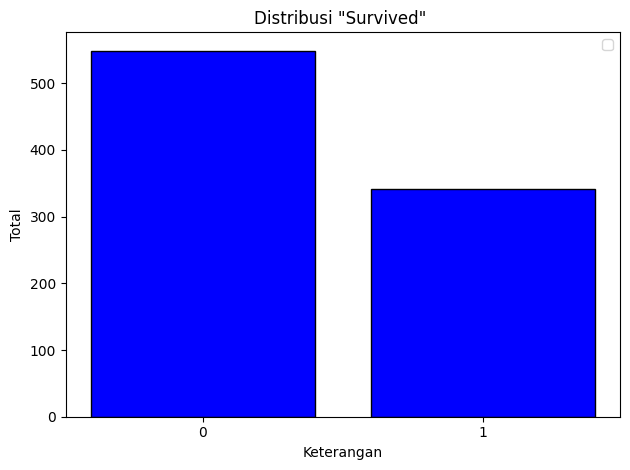

In [ ]:
data = dataset['Survived'].value_counts(ascending=False)
plt.bar(data.index, data.values, color='blue', edgecolor='black')
plt.title('Distribusi "Survived" ')
plt.xlabel("Keterangan")
plt.ylabel('Total')
plt.tight_layout()
plt.xticks(data.index)
plt.show()

## Menyusun Hipotesis / dugaan awal
1. Dipengaruhi karena status gender / jenis kelamin
2. Dipengaruhi Karena umur penumpang yang berbeda
3. Dipengaruhi karena lokasi kelas penumpang yang berbeda
4. Dipengaruhi Karena Harga tiket sehingga prioritas keselamatn penumpang yang berbeda

## 1. Survived by Sex
Hasil Observasi: Terbukti melalui data terjadi perbedaan yang cukup signifikan antara Perempuan
dan laki-laki jika dilihat berdasarkan yang bertahan hidup, dimana perempuan lebih banyak 2 kali dibandingkan dengan laki-laki

In [ ]:
pd.crosstab(dataset['Survived'], dataset['Sex'])


Sex,female,male
Survived,,
0,81,468
1,233,109


## 2. Survived by Age
Hasil Observasi: Terbukti terjadi perbedaan angka yang cukup signifikan antara rentang usia dengan tingkat kematian tertinggi: Anak(dewasa) Muda, Orang dewasa, Remaja, anak-anak, lanjut usia. Lalu tingkat selamat tertinggi: Anak(dewasa) Muda, Orang dewasa, anak anak, remaja, lanjut usia


In [28]:
# Kita pisahkan terlebih dahulu umur berdasarka anak anak dewasa dst...
Umur = [0, 12, 18, 35, 60, 100]
Ket_Label = ["Child", "Teen", "Young Adult", "Adult", "Senior"]

dataset["Label Umur"] = pd.cut(dataset["Age"], bins=Umur, labels=Ket_Label)
# Cut = batas kiri tidak masuk dan batas kanan masuk 

pd.crosstab(dataset['Label Umur'], dataset['Survived'])

Survived,0,1
Label Umur,,
Child,29,40
Teen,40,30
Young Adult,221,137
Adult,117,78
Senior,17,5


## 3. Survived by Pclass
Hasil Observasi: Terbukti bahwa penumpang dengan dengan kelas 1 memiliki tingkat ekhidupan yang paling tinggi disertai dengan tingkat kematian yang paling rendah sedangkan Penumpang kelas 3 memiliki tingkat kematian yang tertinggi dan Penumpang kelas 2 memiliki tingkat kehidupan paling rendah

In [30]:
pd.crosstab(dataset['Pclass'], dataset['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


## 4. Survived by Fare
Hasil Observasi: Terbukti bahwa adanya kerentangan berdasarkan Harga tiket penumpang dengan kelas paling bawah memiliki kematian paling tinggi dan kehidupan paling rendah sedangkan penumpang tiket paling mahal memiliki kematian paling rendah disertai dengan kehidupan paling tinggi

In [32]:
# Karena tingginya rentang harga tiket maka disini kita akan mengelompokkan terlebih dahulu seperti kolom umur
dataset["Ket Kelas"] = pd.qcut(dataset["Fare"],q = 4, labels = ["Low","Mid","High","Very High"])
pd.crosstab(dataset['Ket Kelas'], dataset['Survived'])

Survived,0,1
Ket Kelas,,
Low,179,44
Mid,156,68
High,121,101
Very High,93,129


Kesimpulan: Tingkat Kehidupan dan Kematian Penumpang terbukti melalui data sangat besar dipengaruhi oleh Umur, Harga tiket, Kelas ruangan, Jenis kelamin. (Mungkin seharusnya diurutkan, Diberi lebih banyak Visualisasi dan keterangan keterangan yang lebih lengkap dan lebih bagus seperti jalan atau prosesnya analisa)

Next (Kalau ingat: feature engineering and modeling)